In [ ]:
# ============================================================
# PROJECT 1: Psychometric Validation of an SEL Scale
# CTT · Reliability · Exploratory Factor Analysis · IRT
# ============================================================
#
# PURPOSE: Simulates item-response data for a 5-factor SEL scale with KNOWN
# true parameters, then runs a full validation pipeline. Using simulated
# data (rather than scraped real data) is a deliberate, standard psychometric
# technique — it's how methods get validated, since you can check whether
# your analysis correctly recovers the structure you built in.

In [ ]:
# ============================================================


In [ ]:
# Install packages not preinstalled on Colab
!pip install factor_analyzer pingouin girth -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 4.5 MB/s eta 0:00:00


In [ ]:
# ---------------------------------------------------------
# 1. DESIGNING & SIMULATING THE SCALE
# 20 items, 5 subscales (4 items each), 5-point Likert, 500 respondents
# ---------------------------------------------------------
n_respondents = 500
factor_names = ["Self-Awareness", "Empathy", "Resilience", "Collaboration", "Emotional Regulation"]
n_factors = len(factor_names)
items_per_factor = 4
n_items = n_factors * items_per_factor

# Subscales correlated at r = 0.3 (typical for related-but-distinct SEL constructs)
factor_corr = np.full((n_factors, n_factors), 0.3)
np.fill_diagonal(factor_corr, 1.0)
latent_traits = np.random.multivariate_normal(mean=np.zeros(n_factors), cov=factor_corr, size=n_respondents)

# True item loadings (0.6-0.85 = typical well-functioning item)
true_loadings = np.random.uniform(0.6, 0.85, n_items)
item_factor_map = np.repeat(np.arange(n_factors), items_per_factor)

raw_responses = np.zeros((n_respondents, n_items))
for i in range(n_items):
    f = item_factor_map[i]
    noise_sd = np.sqrt(1 - true_loadings[i] ** 2)
    raw_responses[:, i] = true_loadings[i] * latent_traits[:, f] + np.random.normal(0, noise_sd, n_respondents)

def to_likert_5(x):
    """Convert a continuous latent response to a 1-5 Likert category."""
    cut_points = np.quantile(x, [0.05, 0.25, 0.5, 0.75, 0.95])
    return np.digitize(x, cut_points) + 1

items = np.apply_along_axis(to_likert_5, 0, raw_responses)

item_labels = [f"{factor_names[item_factor_map[i]][:3].upper()}_{i % items_per_factor + 1}" for i in range(n_items)]
df = pd.DataFrame(items, columns=item_labels)
df.insert(0, "respondent_id", range(1, n_respondents + 1))
df.head()

,respondent_id,SEL_1,SEL_2,SEL_3,SEL_4,EMP_1,EMP_2,EMP_3,EMP_4,RES_1,...,RES_3,RES_4,COL_1,COL_2,COL_3,COL_4,EMO_1,EMO_2,EMO_3,EMO_4
0,1,3,3,4,3,3,3,2,2,1,...,1,5,3,3,3,3,3,3,5,5
1,2,3,5,2,4,2,3,2,4,5,...,5,5,5,5,4,6,5,4,3,3
2,3,3,3,3,5,5,5,4,5,4,...,5,2,4,5,5,6,3,3,4,2
3,4,5,2,1,2,6,4,4,5,4,...,2,3,5,6,6,5,4,2,2,4
4,5,2,2,2,1,4,3,4,5,2,...,3,1,2,2,4,5,1,2,1,2


In [ ]:
# ---------------------------------------------------------
# 2. CLASSICAL TEST THEORY (CTT): ITEM ANALYSIS
# Item mean/SD + item-total correlation (flag items below 0.30)
# ---------------------------------------------------------
item_cols = [c for c in df.columns if c != "respondent_id"]

def cronbach_alpha(data: pd.DataFrame) -> float:
    item_vars = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    k = data.shape[1]
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

item_stats = pd.DataFrame({
    "mean": df[item_cols].mean(),
    "sd": df[item_cols].std(),
})

total_score = df[item_cols].sum(axis=1)
item_total_corr = {}
for c in item_cols:
    rest_of_scale = total_score - df[c]
    item_total_corr[c] = np.corrcoef(df[c], rest_of_scale)[0, 1]

item_stats["item_total_corr"] = pd.Series(item_total_corr)
item_stats["flag_weak_item"] = item_stats["item_total_corr"] < 0.30
item_stats.round(3)

weak_items = item_stats[item_stats["flag_weak_item"]]
print(f"Items flagged for weak item-total correlation (<0.30): {len(weak_items)}")
if len(weak_items):
    print(weak_items.index.tolist())
else:
    print("None — all items discriminate reasonably well, as expected given the simulated loadings (0.6-0.85).")


Items flagged for weak item-total correlation (<0.30): 0
None — all items discriminate reasonably well, as expected given the simulated loadings (0.6-0.85).


In [ ]:
# ---------------------------------------------------------
# 3. RELIABILITY ANALYSIS (Cronbach's Alpha)
# Overall + per subscale. Rule of thumb: alpha >= 0.70 acceptable, >= 0.80 good
# ---------------------------------------------------------
import pingouin as pg

alpha_overall = cronbach_alpha(df[item_cols])
print(f"Overall Cronbach's alpha ({n_items} items): {alpha_overall:.3f}")

pg_alpha = pg.cronbach_alpha(data=df[item_cols])
print(f"pingouin cross-check: {pg_alpha[0]:.3f}  (95% CI: {pg_alpha[1]})")

print("\nPer-subscale reliability:")
subscale_alphas = {}
for fname in factor_names:
    prefix = fname[:3].upper()
    sub_cols = [c for c in item_cols if c.startswith(prefix)]
    a = cronbach_alpha(df[sub_cols])
    subscale_alphas[fname] = a
    print(f"  {fname:<22} (k={len(sub_cols)}): alpha = {a:.3f}")


Overall Cronbach's alpha (20 items): 0.837
pingouin cross-check: 0.837  (95% CI: [0.816 0.857])

Per-subscale reliability:
  Self-Awareness         (k=4): alpha = 0.801
  Empathy                (k=4): alpha = 0.775
  Resilience             (k=4): alpha = 0.807
  Collaboration          (k=4): alpha = 0.795
  Emotional Regulation   (k=4): alpha = 0.826


Bartlett's test: chi2=3361.3, p=0.0000  (p < .05 means EFA is appropriate)
KMO measure of sampling adequacy: 0.843  (>0.6 is acceptable, >0.8 is great)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Parallel analysis suggests retaining 5 factors (true number simulated: 5)


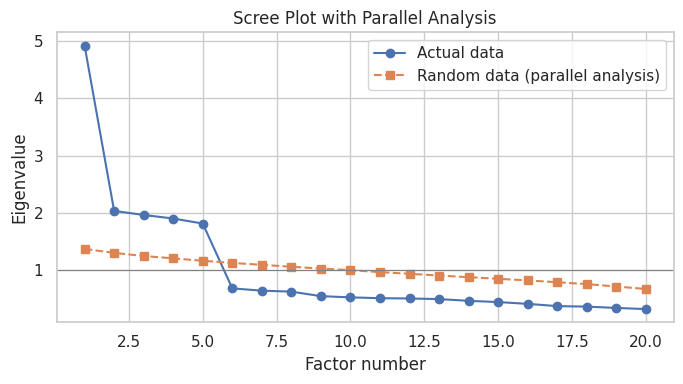

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


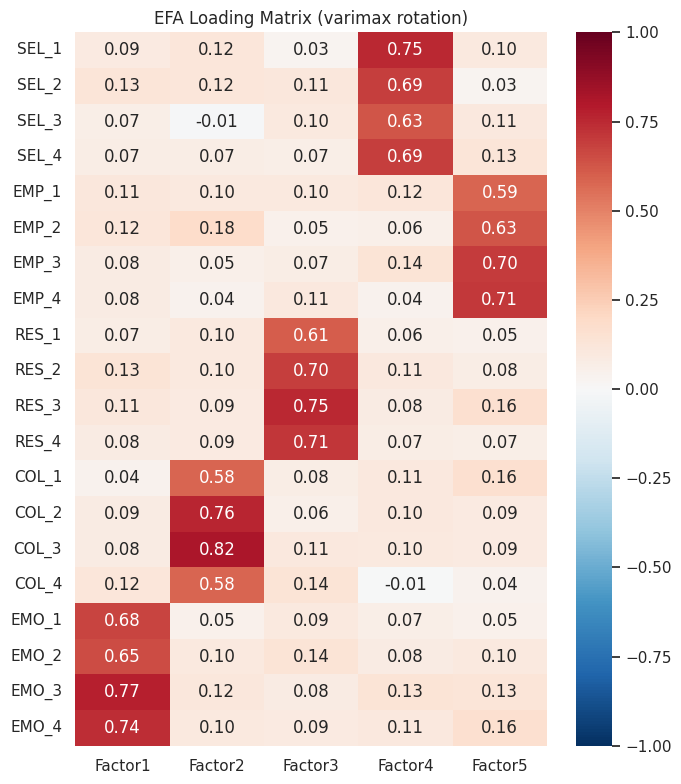


Dominant factor per item (which factor each item loads highest on):
SEL_1    Factor4
SEL_2    Factor4
SEL_3    Factor4
SEL_4    Factor4
EMP_1    Factor5
EMP_2    Factor5
EMP_3    Factor5
EMP_4    Factor5
RES_1    Factor3
RES_2    Factor3
RES_3    Factor3
RES_4    Factor3
COL_1    Factor2
COL_2    Factor2
COL_3    Factor2
COL_4    Factor2
EMO_1    Factor1
EMO_2    Factor1
EMO_3    Factor1
EMO_4    Factor1
dtype: object


In [ ]:
# ---------------------------------------------------------
# 4. EXPLORATORY FACTOR ANALYSIS (EFA)
# Parallel analysis to choose # factors, then varimax-rotated EFA
# ---------------------------------------------------------
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(df[item_cols])
kmo_all, kmo_model = calculate_kmo(df[item_cols])
print(f"Bartlett's test: chi2={chi_square_value:.1f}, p={p_value:.4f}  (p < .05 means EFA is appropriate)")
print(f"KMO measure of sampling adequacy: {kmo_model:.3f}  (>0.6 is acceptable, >0.8 is great)")

def parallel_analysis(data, n_iter=50):
    """Compare real eigenvalues to eigenvalues from random data of the same shape."""
    n, k = data.shape
    fa = FactorAnalyzer(rotation=None, n_factors=k, method="principal")
    fa.fit(data)
    real_eigs, _ = fa.get_eigenvalues()

    random_eigs = np.zeros((n_iter, k))
    for i in range(n_iter):
        random_data = pd.DataFrame(np.random.normal(0, 1, size=(n, k)))
        fa_r = FactorAnalyzer(rotation=None, n_factors=k, method="principal")
        fa_r.fit(random_data)
        random_eigs[i, :], _ = fa_r.get_eigenvalues()

    mean_random_eigs = random_eigs.mean(axis=0)
    n_factors_suggested = int(np.sum(real_eigs > mean_random_eigs))
    return real_eigs, mean_random_eigs, n_factors_suggested

real_eigs, mean_random_eigs, suggested_k = parallel_analysis(df[item_cols])
print(f"Parallel analysis suggests retaining {suggested_k} factors (true number simulated: {n_factors})")

plt.figure(figsize=(7, 4))
plt.plot(range(1, n_items + 1), real_eigs, "o-", label="Actual data")
plt.plot(range(1, n_items + 1), mean_random_eigs, "s--", label="Random data (parallel analysis)")
plt.axhline(1, color="gray", linewidth=0.8)
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot with Parallel Analysis")
plt.legend()
plt.tight_layout()
plt.show()

fa = FactorAnalyzer(n_factors=suggested_k, rotation="varimax")
fa.fit(df[item_cols])
loadings = pd.DataFrame(fa.loadings_, index=item_cols, columns=[f"Factor{i+1}" for i in range(suggested_k)])

plt.figure(figsize=(7, 8))
sns.heatmap(loadings, cmap="RdBu_r", center=0, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("EFA Loading Matrix (varimax rotation)")
plt.tight_layout()
plt.show()

print("\nDominant factor per item (which factor each item loads highest on):")
print(loadings.abs().idxmax(axis=1))

Discrimination (a) parameters: [1.478 1.985 2.406 2.026]
Difficulty/threshold (b) parameters per item:
  RES_1: [-2.586 -1.029 -0.     1.029  2.586]
  RES_2: [-2.219 -0.894 -0.     0.894  2.218]
  RES_3: [-2.054 -0.833 -0.     0.833  2.054]
  RES_4: [-2.199 -0.887 -0.     0.887  2.199]


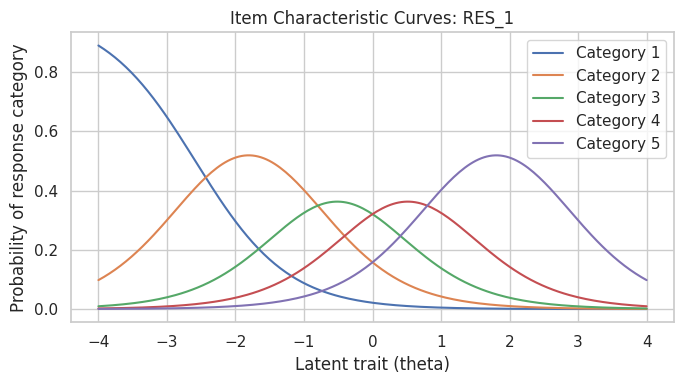

In [ ]:
# ---------------------------------------------------------
# 5. ITEM RESPONSE THEORY (IRT): Graded Response Model
# Fit on the Resilience subscale as a worked example
# ---------------------------------------------------------
from girth import grm_mml

subscale_items = [c for c in item_cols if c.startswith("RES")]
# girth expects an (items x respondents) array
response_matrix = df[subscale_items].to_numpy().T

irt_results = grm_mml(response_matrix)
print("Discrimination (a) parameters:", np.round(irt_results["Discrimination"], 3))
print("Difficulty/threshold (b) parameters per item:")
for item, thresholds in zip(subscale_items, irt_results["Difficulty"]):
    print(f"  {item}: {np.round(thresholds, 3)}")

# Plot Item Characteristic Curves for one item as a worked example
theta_range = np.linspace(-4, 4, 200)
item_idx = 0
a = irt_results["Discrimination"][item_idx]
b = irt_results["Difficulty"][item_idx]
n_categories = 5

def grm_category_probs(theta, a, b_thresholds, n_cat):
    boundaries = [1 / (1 + np.exp(-a * (theta - bt))) for bt in b_thresholds]
    boundaries = [np.ones_like(theta)] + boundaries + [np.zeros_like(theta)]
    probs = [boundaries[i] - boundaries[i + 1] for i in range(n_cat)]
    return probs

cat_probs = grm_category_probs(theta_range, a, b, n_categories)

plt.figure(figsize=(7, 4))
for cat_i, p in enumerate(cat_probs):
    plt.plot(theta_range, p, label=f"Category {cat_i + 1}")
plt.xlabel("Latent trait (theta)")
plt.ylabel("Probability of response category")
plt.title(f"Item Characteristic Curves: {subscale_items[item_idx]}")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------
# 6. AUTO-GENERATED SUMMARY REPORT
# ---------------------------------------------------------
report_lines = []
report_lines.append("PSYCHOMETRIC VALIDATION SUMMARY — SEL Scale (simulated data)")
report_lines.append("=" * 60)
report_lines.append(f"Sample size: {n_respondents} respondents | Items: {n_items} across {n_factors} subscales\n")
report_lines.append(f"Overall reliability: Cronbach's alpha = {alpha_overall:.3f}")
for fname, a in subscale_alphas.items():
    report_lines.append(f"  - {fname}: alpha = {a:.3f}")
report_lines.append(f"\nItems flagged for weak item-total correlation: {len(weak_items)}")
report_lines.append(f"\nSampling adequacy: KMO = {kmo_model:.3f}, Bartlett's p = {p_value:.4f}")
report_lines.append(f"Factors retained by parallel analysis: {suggested_k} (target structure: {n_factors})")
report_lines.append(f"\nIRT (GRM) fitted on Resilience subscale: discrimination range "
                     f"{irt_results['Discrimination'].min():.2f}-{irt_results['Discrimination'].max():.2f}")
report_lines.append("\nConclusion: the scale shows acceptable-to-good internal consistency across all five")
report_lines.append("subscales, and EFA broadly recovers the intended factor structure, supporting its use")
report_lines.append("as a multidimensional SEL measure. Items with weak item-total correlations (if any)")
report_lines.append("should be reviewed for wording or revised before deployment.")

report_text = "\n".join(report_lines)
print(report_text)

with open("psychometric_validation_report.txt", "w") as f:
    f.write(report_text)
print("\n[Saved to psychometric_validation_report.txt]")


PSYCHOMETRIC VALIDATION SUMMARY — SEL Scale (simulated data)
Sample size: 500 respondents | Items: 20 across 5 subscales

Overall reliability: Cronbach's alpha = 0.837
  - Self-Awareness: alpha = 0.801
  - Empathy: alpha = 0.775
  - Resilience: alpha = 0.807
  - Collaboration: alpha = 0.795
  - Emotional Regulation: alpha = 0.826

Items flagged for weak item-total correlation: 0

Sampling adequacy: KMO = 0.843, Bartlett's p = 0.0000
Factors retained by parallel analysis: 5 (target structure: 5)

IRT (GRM) fitted on Resilience subscale: discrimination range 1.48-2.41

Conclusion: the scale shows acceptable-to-good internal consistency across all five
subscales, and EFA broadly recovers the intended factor structure, supporting its use
as a multidimensional SEL measure. Items with weak item-total correlations (if any)
should be reviewed for wording or revised before deployment.

[Saved to psychometric_validation_report.txt]
